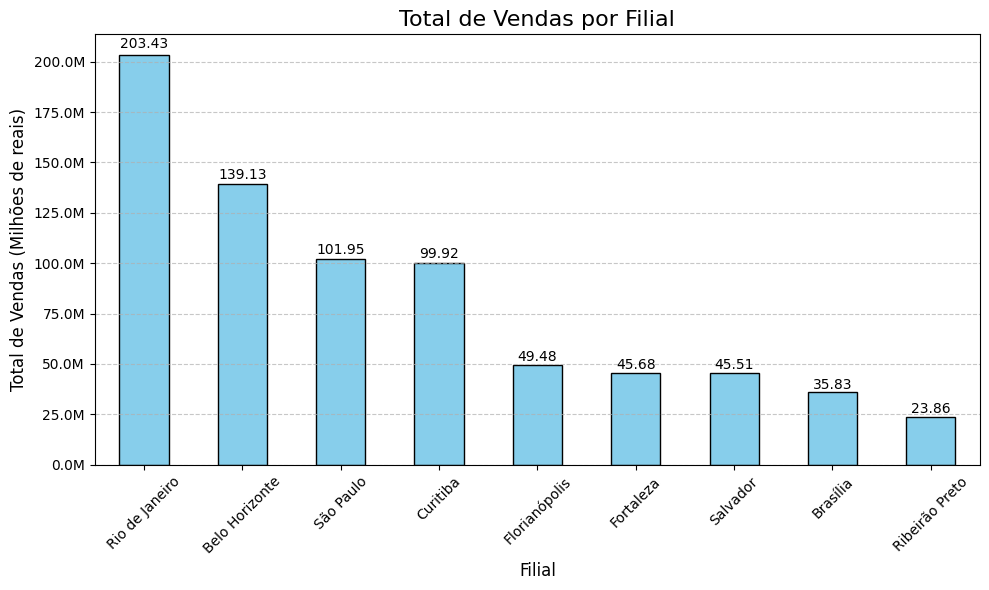

In [5]:

'''



RESUMO:
======
O que este código faz?
Lê os dados da planilha do Excel.

Agrupa as vendas por filial.

Soma o total de vendas de cada filial.

Ordena do maior para o menor.

Cria um gráfico de barras claro e fácil de entender.



'''




# Importa a biblioteca pandas para ler planilhas e trabalhar com dados
import pandas as pd

# Importa a biblioteca para fazer gráficos
import matplotlib.pyplot as plt

# Importa uma ferramenta que permite formatar os números no gráfico
# principalmente no eixo vertical (Y) de forma mais eficiente
import matplotlib.ticker as ticker

# 🔹 CAMINHO DO ARQUIVO NO SEU COMPUTADOR:
caminho_arquivo = r'C:\Rafaélla Sena - Python\Python 2\Python 2 - Clarify\Aluno\Aula_02\Projeto\Bases Projeto\01.Vendas Carros.xlsx'

# Lê os dados da planilha Excel
df = pd.read_excel(caminho_arquivo, sheet_name= 'Planilha1')

# Agrupa os dados pela coluna 'Filial' e soma os valores da coluna 'Total Vendas'
vendas_por_filial = df.groupby('Filial') ['Total Vendas'].sum()

# Ordena os resultados do maior valor de venda para o menor
vendas_por_filial = vendas_por_filial.sort_values(ascending=False)

# Cria uma nova 'área' para desenhar o gráfico
plt.figure(figsize = (10,6))

# Cria o gráfico de barras verticais com as vendas por filial
#kind = tipo de gráfico
vendas_por_filial.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')

# Adiciona o título na parte de cima do gráfico
plt.title('Total de Vendas por Filial', fontsize = 16)

#Nome do eixo horizontal(embaixo do gráfico)
plt.xlabel('Filial', fontsize = 12)

# Nome do eixo vertical (lado esquerdo do gráfico)
# Agora avisamos que os valores estão em milhões de reais
plt.ylabel('Total de Vendas (Milhões de reais)', fontsize = 12)

# Pega os 'eixos' do gráfico (horizontal e vertical)
#gca = significa Get Current Axes, pega os eixos atuais do gráfico
eixos = plt.gca()

# Formata o eixo vertical (Y) para mostrar os números em milhões (ex: 1.5M)
eixos.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Explicação:
# - lambda x, _: função que recebe o valor (x)
# - x/1e6 → divide por 1.000.000 (para transformar em milhões)
# - .1f → mostra 1 casa decimal (ex: 2.3M)
# - f'{...}M' → formatar valor ( caso queira colocar a letra M depois do número (ex: 2.3M))


# ADICIONAR / MOSTRAR os valores no topo das barras
for i, valor in enumerate(vendas_por_filial):
    plt.text(
        i, #posição no eixo x (barra atual)
    #posição no eixo Y(um pouco acima da barra)
    valor + valor * 0.01,
    #texto a ser mostrado (em milhões com 2 casas decimais)
    f'{valor/1e6:.2f}',
    #alinhamento horizontal centralido
    ha = 'center', 
    #alinhamento vertical: base da letra encosta no topo da barra
    va = 'bottom',
    fontsize = 10,
    color = 'black'
    )

# Gira os nomes das filiais no eixo X para não ficarem tortos
plt.xticks(rotation = 45)

# Adiciona linhas horizontais para facilitar a visualização
plt.grid(axis='y',linestyle = '--', alpha = 0.7)

# axis='y' → só no eixo Y
# linestyle='--' → linha pontilhada
# alpha=0.7 → transparência da linha (vai de 0 a 1)

# Ajusta o tamanho e espaço do gráfico automaticamente
plt.tight_layout()

# Mostra o gráfico na tela
plt.show()

